In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from catboost import CatBoostClassifier

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score,
    precision_recall_curve
)

sns.set_theme(
    style="whitegrid",
    context="notebook"
)

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["font.size"] = 11

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
data = load_breast_cancer(as_frame=True)

X = data.data
y = data.target

df = X.copy()
df["Target"] = y

print("Dataset Shape:", df.shape)

display(df.head(10))

Dataset Shape: (569, 31)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,Target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0
5,12.45,15.70,82.57,477.1,0.12780,0.17000,0.15780,0.08089,0.2087,0.07613,...,23.75,103.40,741.6,0.1791,0.5249,0.5355,0.1741,0.3985,0.12440,0
6,18.25,19.98,119.60,1040.0,0.09463,0.10900,0.11270,0.07400,0.1794,0.05742,...,27.66,153.20,1606.0,0.1442,0.2576,0.3784,0.1932,0.3063,0.08368,0
7,13.71,20.83,90.20,577.9,0.11890,0.16450,0.09366,0.05985,0.2196,0.07451,...,28.14,110.60,897.0,0.1654,0.3682,0.2678,0.1556,0.3196,0.11510,0
8,13.00,21.82,87.50,519.8,0.12730,0.19320,0.18590,0.09353,0.2350,0.07389,...,30.73,106.20,739.3,0.1703,0.5401,0.5390,0.2060,0.4378,0.10720,0
9,12.46,24.04,83.97,475.9,0.11860,0.23960,0.22730,0.08543,0.2030,0.08243,...,40.68,97.65,711.4,0.1853,1.0580,1.1050,0.2210,0.4366,0.20750,0


In [3]:
print("=" * 70)
print("DATASET INFORMATION")
print("=" * 70)

print("\nDataset Shape:")
print(df.shape)

print("\nNumber of Features:")
print(X.shape[1])

print("\nClass Names:")
print(data.target_names)

print("\nData Types:")
display(X.dtypes.to_frame("Data Type"))

print("\nMissing Values:")
display(X.isnull().sum().to_frame("Missing Values"))

print("\nStatistical Summary:")
display(X.describe().T)

DATASET INFORMATION

Dataset Shape:
(569, 31)

Number of Features:
30

Class Names:
['malignant' 'benign']

Data Types:


,Data Type
mean radius,float64
mean texture,float64
mean perimeter,float64
mean area,float64
mean smoothness,float64
mean compactness,float64
mean concavity,float64
mean concave points,float64
mean symmetry,float64
mean fractal dimension,float64



Missing Values:


,Missing Values
mean radius,0
mean texture,0
mean perimeter,0
mean area,0
mean smoothness,0
mean compactness,0
mean concavity,0
mean concave points,0
mean symmetry,0
mean fractal dimension,0



Statistical Summary:


,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


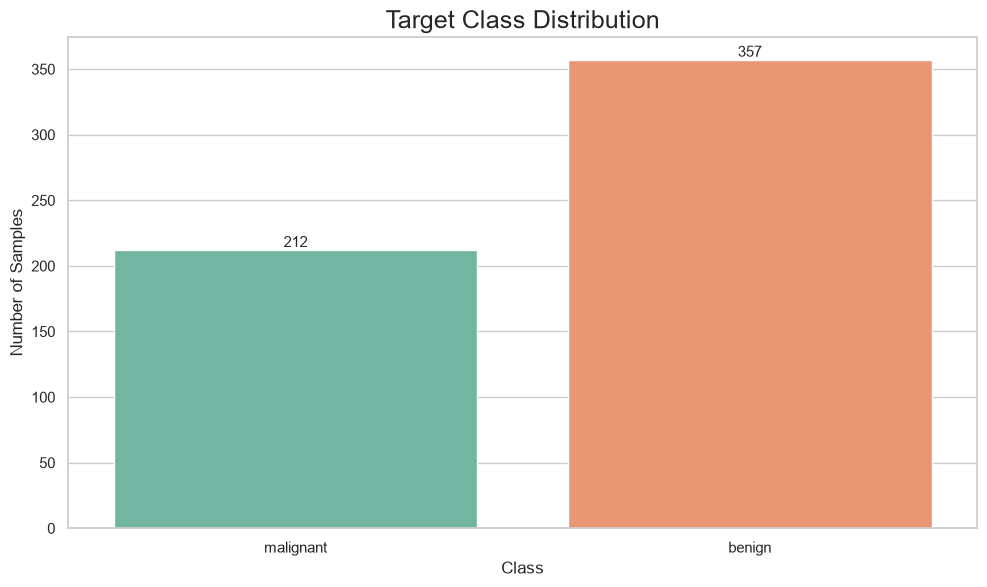

In [4]:
class_counts = y.value_counts().sort_index()

class_labels = [
    data.target_names[i]
    for i in class_counts.index
]

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    x=class_labels,
    y=class_counts.values,
    hue=class_labels,
    palette="Set2",
    legend=False
)

plt.title("Target Class Distribution", fontsize=18)
plt.xlabel("Class")
plt.ylabel("Number of Samples")

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

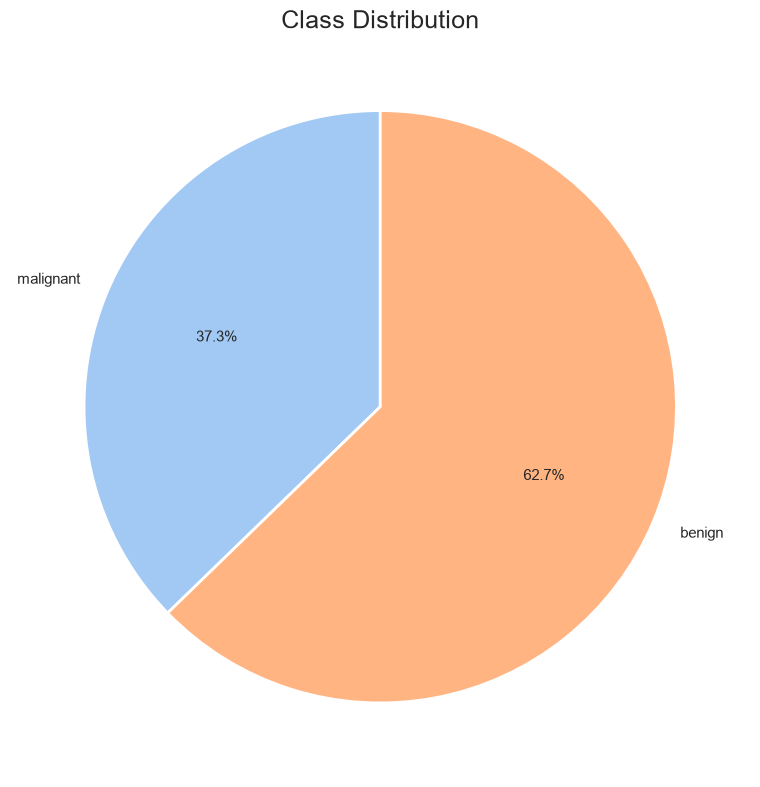

In [5]:
plt.figure(figsize=(8, 8))

plt.pie(
    class_counts.values,
    labels=class_labels,
    autopct="%1.1f%%",
    startangle=90,
    colors=sns.color_palette("pastel"),
    wedgeprops={
        "edgecolor": "white",
        "linewidth": 2
    }
)

plt.title(
    "Class Distribution",
    fontsize=18
)

plt.tight_layout()
plt.show()

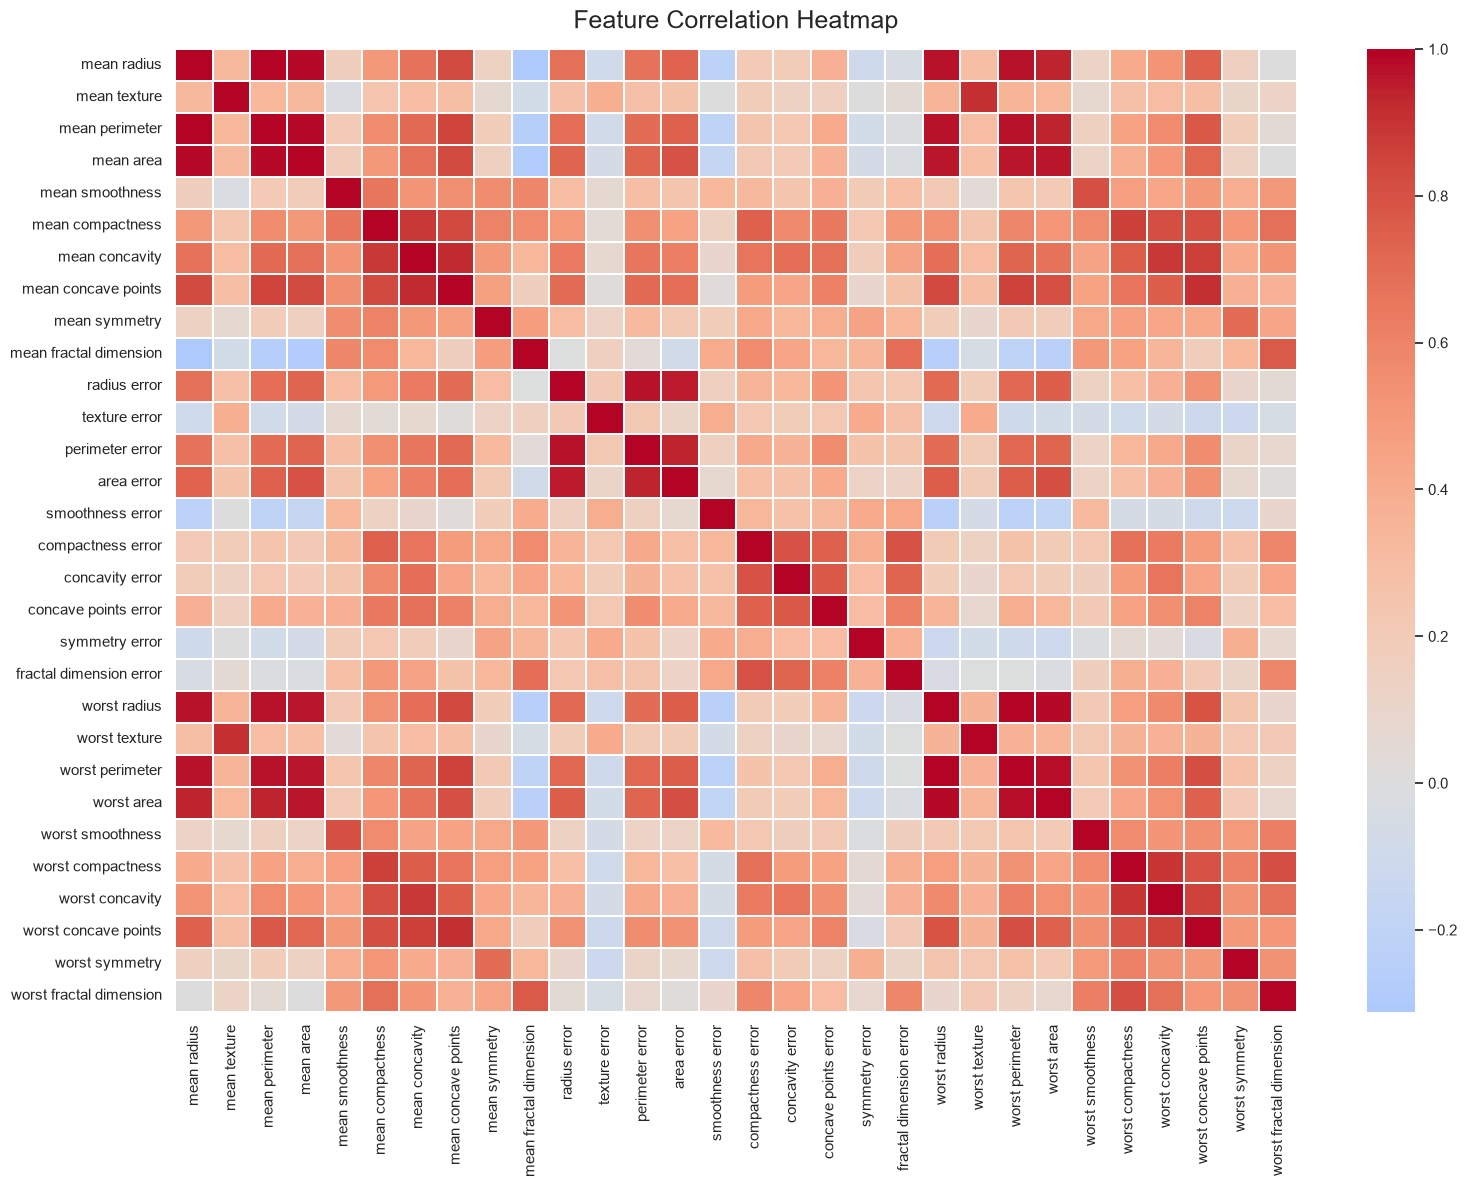

In [6]:
correlation = X.corr()

plt.figure(figsize=(16, 12))

sns.heatmap(
    correlation,
    cmap="coolwarm",
    center=0,
    linewidths=0.2
)

plt.title(
    "Feature Correlation Heatmap",
    fontsize=18,
    pad=15
)

plt.tight_layout()
plt.show()

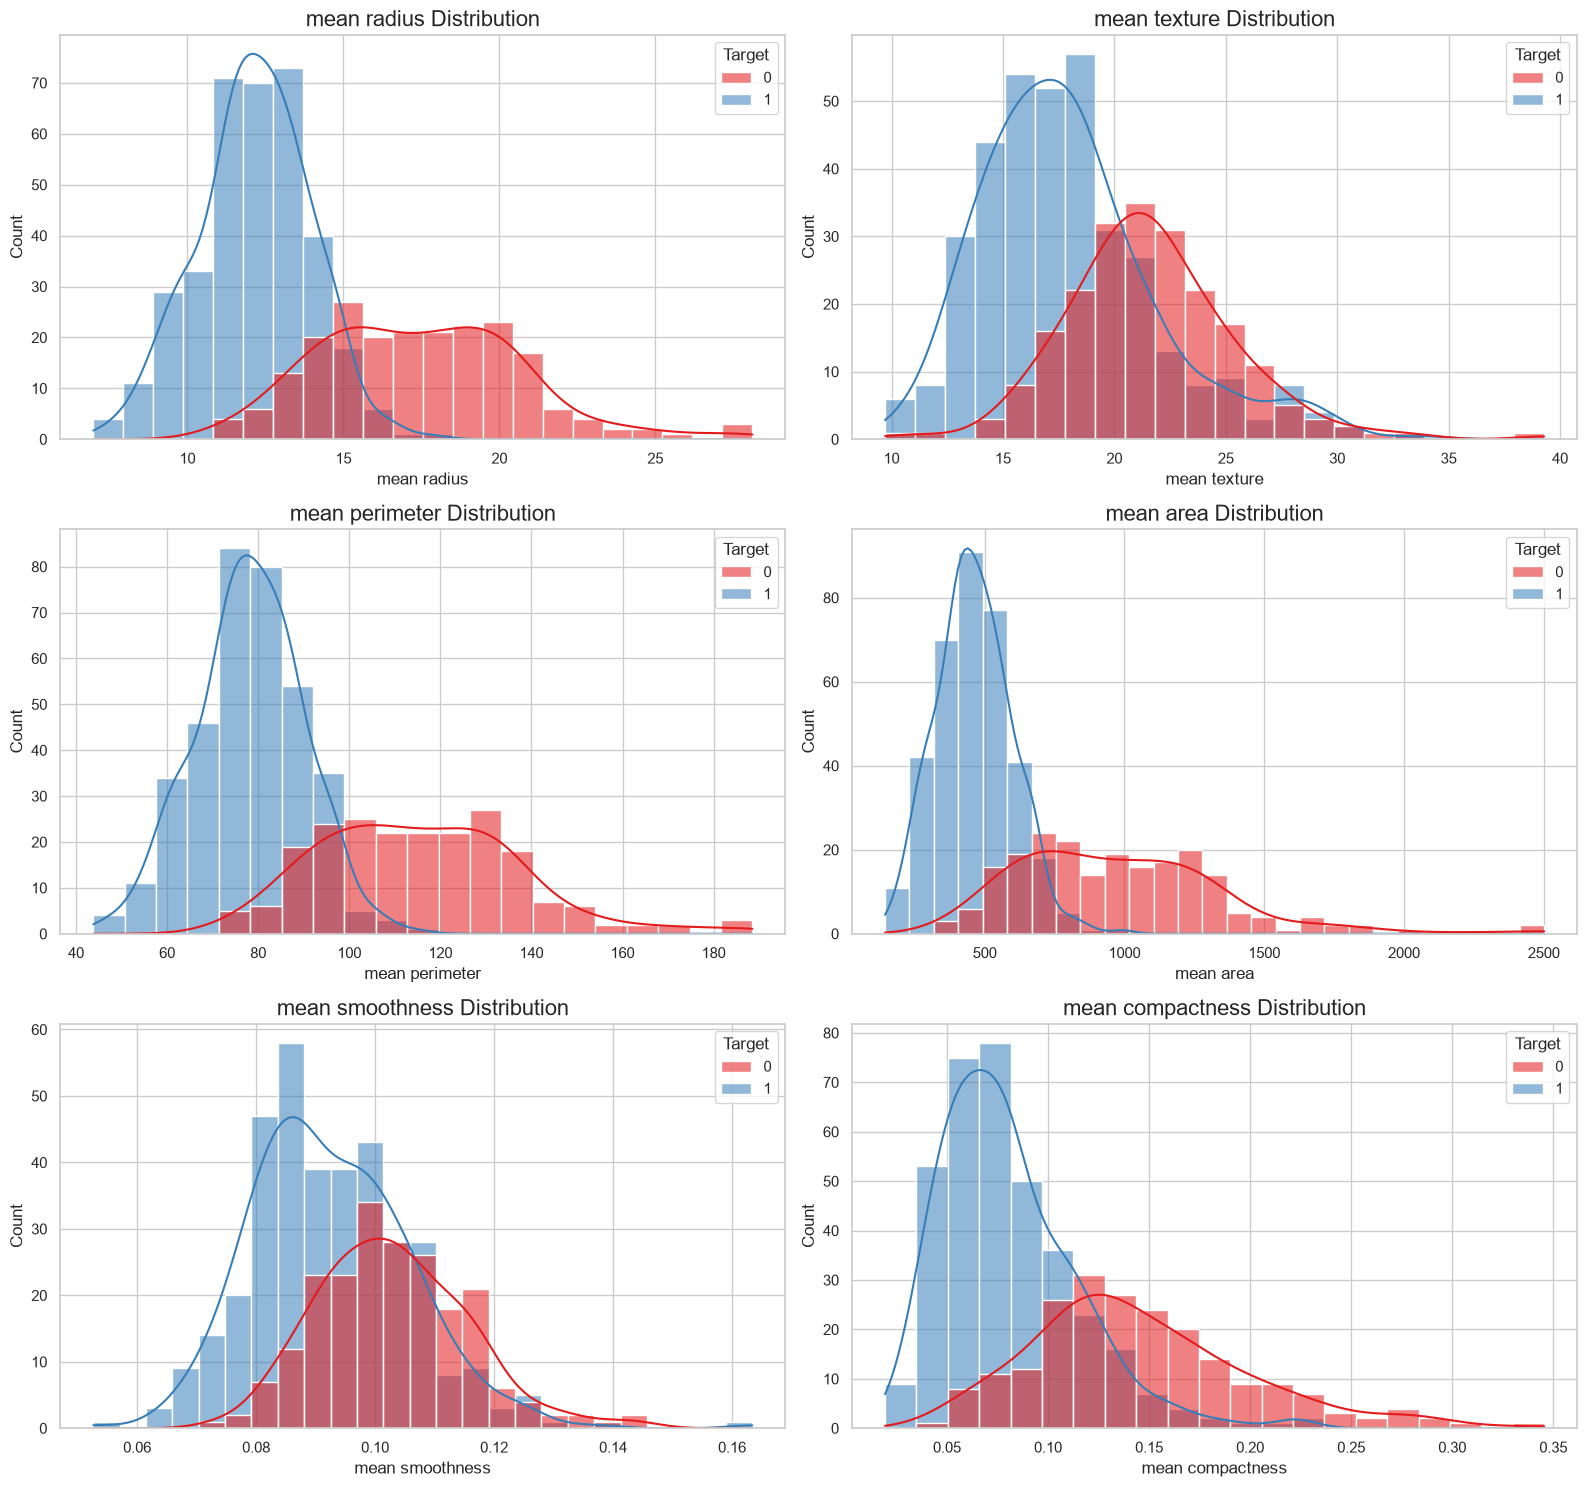

In [7]:
selected_features = [
    "mean radius",
    "mean texture",
    "mean perimeter",
    "mean area",
    "mean smoothness",
    "mean compactness"
]

fig, axes = plt.subplots(
    3,
    2,
    figsize=(16, 15)
)

for ax, feature in zip(
    axes.flatten(),
    selected_features
):

    sns.histplot(
        data=df,
        x=feature,
        hue="Target",
        kde=True,
        palette="Set1",
        alpha=0.55,
        ax=ax
    )

    ax.set_title(
        f"{feature} Distribution"
    )

plt.tight_layout()
plt.show()

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape :", X_test.shape)

print("\nTraining Class Distribution:")
display(y_train.value_counts().sort_index())

print("\nTesting Class Distribution:")
display(y_test.value_counts().sort_index())

Training Data Shape: (455, 30)
Testing Data Shape : (114, 30)

Training Class Distribution:


target
0    170
1    285
Name: count, dtype: int64


Testing Class Distribution:


target
0    42
1    72
Name: count, dtype: int64

In [9]:
model = CatBoostClassifier(
    iterations=700,
    learning_rate=0.05,
    depth=6,
    loss_function="Logloss",
    eval_metric="Accuracy",
    random_seed=42,
    l2_leaf_reg=3,
    random_strength=1,
    bagging_temperature=1,
    verbose=False
)

print(model)

CatBoostClassifier(bagging_temperature=1, depth=6, eval_metric='Accuracy', iterations=700, l2_leaf_reg=3, learning_rate=0.05, loss_function='Logloss', random_seed=42, random_strength=1, verbose=False)


In [10]:
model.fit(
    X_train,
    y_train,
    eval_set=(X_test, y_test),
    use_best_model=True,
    early_stopping_rounds=50,
    verbose=100
)

print("\nCatBoost Classifier training completed!")
print("Best Iteration:", model.get_best_iteration())

0:	learn: 0.9538462	test: 0.9035088	best: 0.9035088 (0)	total: 144ms	remaining: 1m 40s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.9736842105
bestIteration = 4

Shrink model to first 5 iterations.

CatBoost Classifier training completed!
Best Iteration: 4


In [11]:
y_train_pred = model.predict(X_train).flatten()
y_test_pred = model.predict(X_test).flatten()

y_train_proba = model.predict_proba(X_train)[:, 1]
y_test_proba = model.predict_proba(X_test)[:, 1]

prediction_table = pd.DataFrame({
    "Actual": y_test.values[:15],
    "Predicted": y_test_pred[:15],
    "Probability of Class 1": y_test_proba[:15]
})

display(prediction_table)

,Actual,Predicted,Probability of Class 1
0,0,0,0.260078
1,1,1,0.756199
2,0,0,0.425085
3,1,0,0.455882
4,0,0,0.308684
5,1,1,0.695428
6,1,1,0.701165
7,0,0,0.260563
8,0,0,0.300893
9,0,0,0.260078


In [12]:
train_accuracy = accuracy_score(y_train, y_train_pred)
train_precision = precision_score(y_train, y_train_pred)
train_recall = recall_score(y_train, y_train_pred)
train_f1 = f1_score(y_train, y_train_pred)

test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred)
test_recall = recall_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)

metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],
    "Training": [
        train_accuracy,
        train_precision,
        train_recall,
        train_f1
    ],
    "Testing": [
        test_accuracy,
        test_precision,
        test_recall,
        test_f1
    ]
})

display(metrics)

,Metric,Training,Testing
0,Accuracy,0.969231,0.973684
1,Precision,0.968858,0.972603
2,Recall,0.982456,0.986111
3,F1 Score,0.975610,0.979310


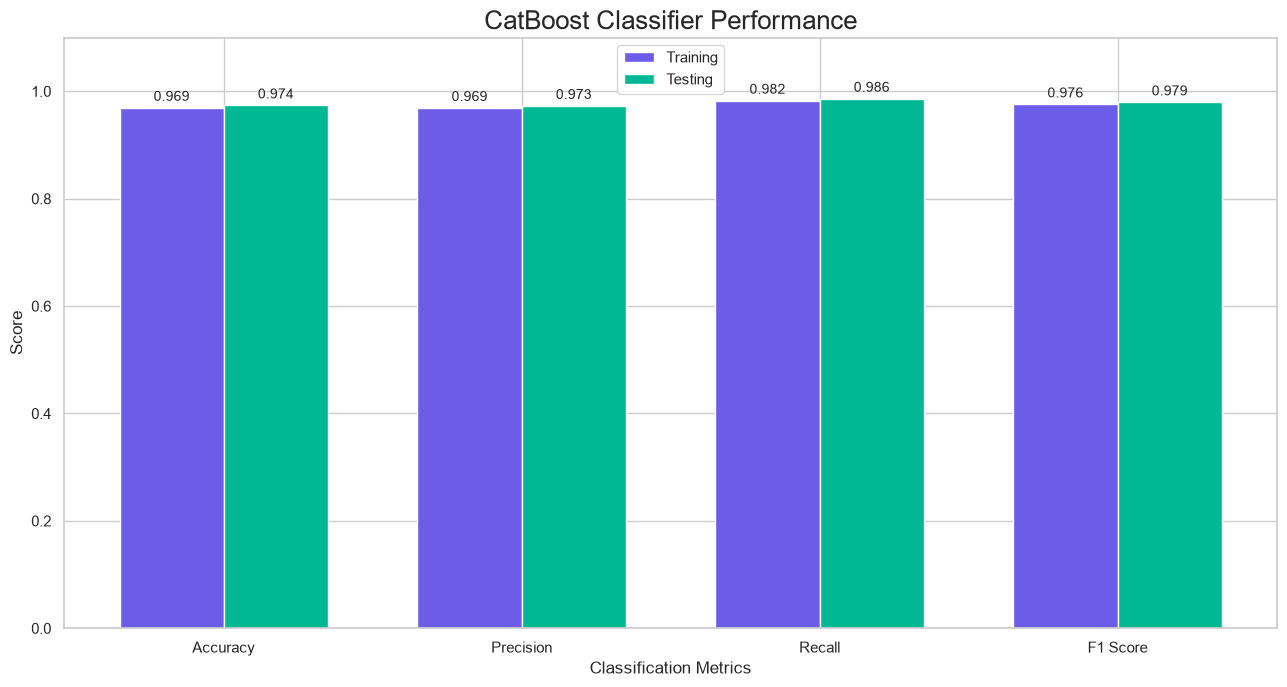

In [13]:
metric_names = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score"
]

train_values = [
    train_accuracy,
    train_precision,
    train_recall,
    train_f1
]

test_values = [
    test_accuracy,
    test_precision,
    test_recall,
    test_f1
]

x = np.arange(len(metric_names))
width = 0.35

fig, ax = plt.subplots(
    figsize=(13, 7)
)

bars1 = ax.bar(
    x - width / 2,
    train_values,
    width,
    label="Training",
    color="#6C5CE7"
)

bars2 = ax.bar(
    x + width / 2,
    test_values,
    width,
    label="Testing",
    color="#00B894"
)

ax.set_title(
    "CatBoost Classifier Performance",
    fontsize=19
)

ax.set_xlabel("Classification Metrics")
ax.set_ylabel("Score")

ax.set_xticks(x)
ax.set_xticklabels(metric_names)

ax.set_ylim(0, 1.1)
ax.legend()

for bars in [bars1, bars2]:
    for bar in bars:

        height = bar.get_height()

        ax.annotate(
            f"{height:.3f}",
            xy=(
                bar.get_x() + bar.get_width() / 2,
                height
            ),
            xytext=(0, 5),
            textcoords="offset points",
            ha="center",
            fontsize=10
        )

plt.tight_layout()
plt.show()

In [14]:
print(
    classification_report(
        y_test,
        y_test_pred,
        target_names=data.target_names
    )
)

              precision    recall  f1-score   support

   malignant       0.98      0.95      0.96        42
      benign       0.97      0.99      0.98        72

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



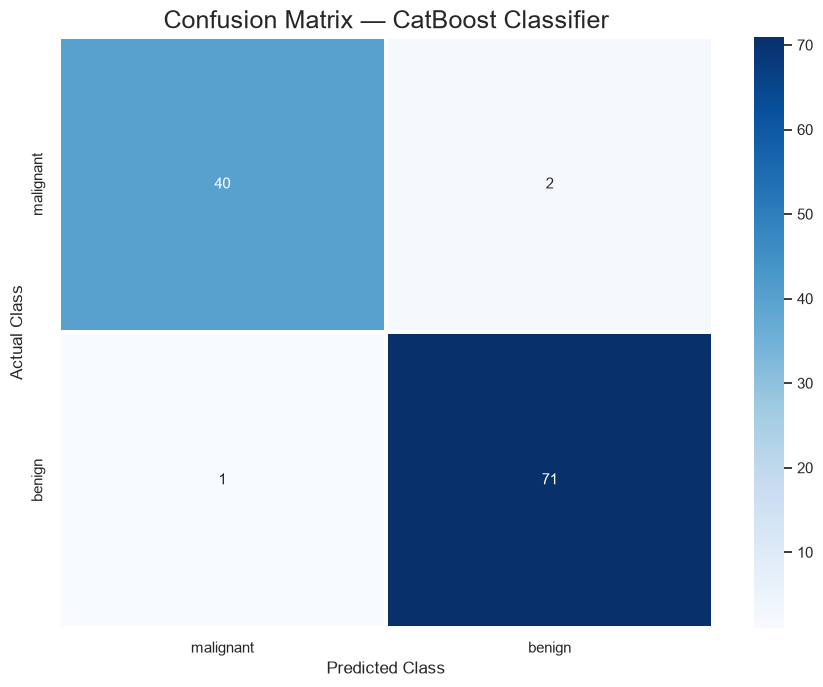

In [15]:
cm = confusion_matrix(
    y_test,
    y_test_pred
)

plt.figure(figsize=(9, 7))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    linewidths=1.5,
    cbar=True,
    xticklabels=data.target_names,
    yticklabels=data.target_names
)

plt.title(
    "Confusion Matrix — CatBoost Classifier",
    fontsize=18
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.tight_layout()
plt.show()

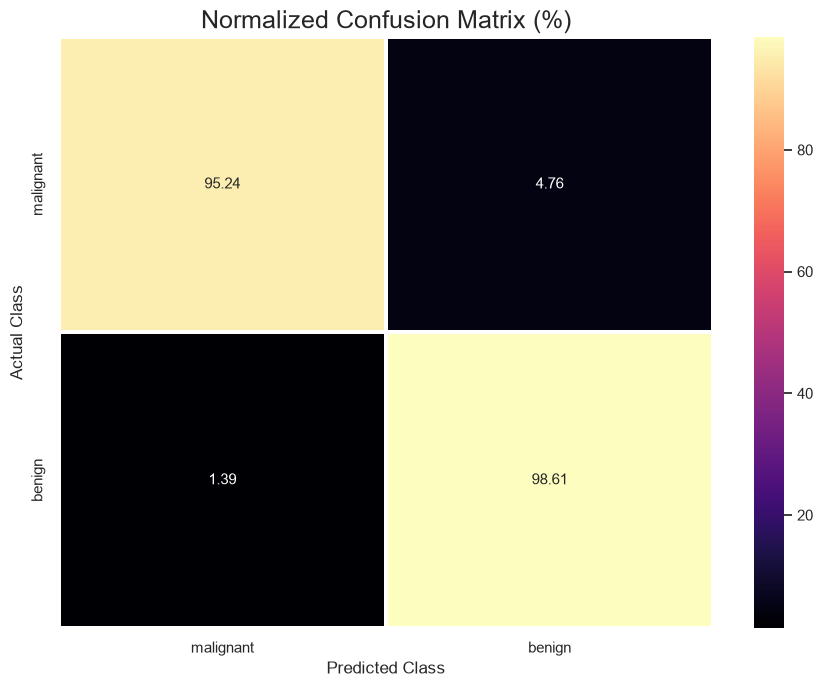

In [16]:
cm_percentage = (
    cm.astype(float)
    / cm.sum(axis=1)[:, np.newaxis]
) * 100

plt.figure(figsize=(9, 7))

sns.heatmap(
    cm_percentage,
    annot=True,
    fmt=".2f",
    cmap="magma",
    linewidths=1.5,
    cbar=True,
    xticklabels=data.target_names,
    yticklabels=data.target_names
)

plt.title(
    "Normalized Confusion Matrix (%)",
    fontsize=18
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.tight_layout()
plt.show()

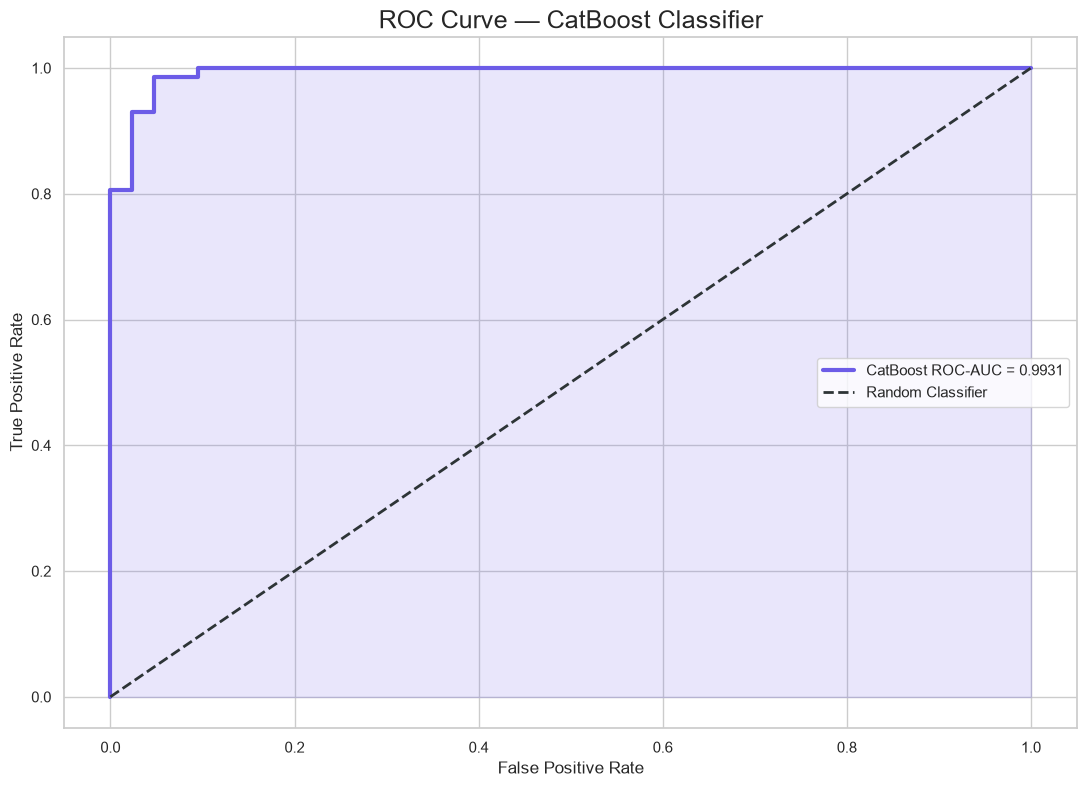

ROC-AUC Score: 0.9931


In [17]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_test_proba
)

auc_score = roc_auc_score(
    y_test,
    y_test_proba
)

plt.figure(figsize=(11, 8))

plt.plot(
    fpr,
    tpr,
    color="#6C5CE7",
    linewidth=3,
    label=f"CatBoost ROC-AUC = {auc_score:.4f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    color="#2D3436",
    linestyle="--",
    linewidth=2,
    label="Random Classifier"
)

plt.fill_between(
    fpr,
    tpr,
    alpha=0.15,
    color="#6C5CE7"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    "ROC Curve — CatBoost Classifier",
    fontsize=18
)

plt.legend()
plt.tight_layout()
plt.show()

print(f"ROC-AUC Score: {auc_score:.4f}")

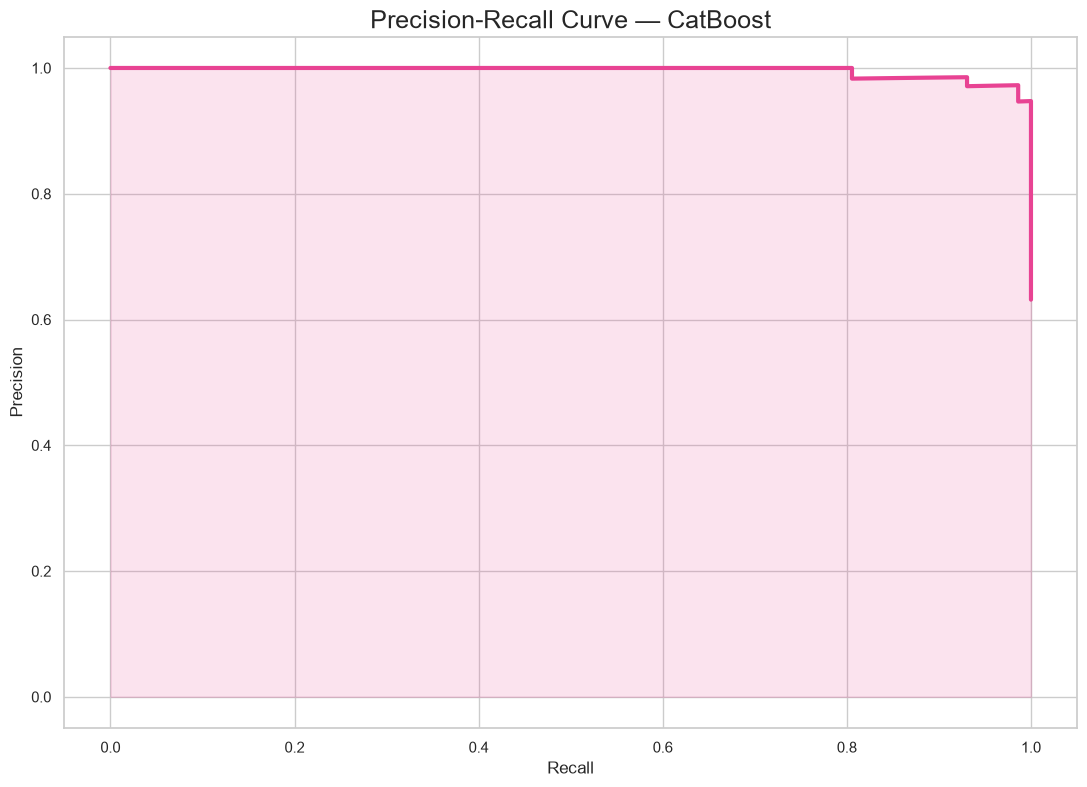

In [18]:
precision, recall, pr_thresholds = precision_recall_curve(
    y_test,
    y_test_proba
)

plt.figure(figsize=(11, 8))

plt.plot(
    recall,
    precision,
    color="#E84393",
    linewidth=3
)

plt.fill_between(
    recall,
    precision,
    alpha=0.15,
    color="#E84393"
)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title(
    "Precision-Recall Curve — CatBoost",
    fontsize=18
)

plt.tight_layout()
plt.show()

In [19]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.get_feature_importance()
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

display(
    feature_importance.head(20)
)

,Feature,Importance
27,worst concave points,15.973531
22,worst perimeter,13.957195
23,worst area,10.442720
20,worst radius,10.228519
18,symmetry error,7.002831
25,worst compactness,6.761549
10,radius error,6.288453
29,worst fractal dimension,6.014567
2,mean perimeter,4.495410
21,worst texture,4.280769


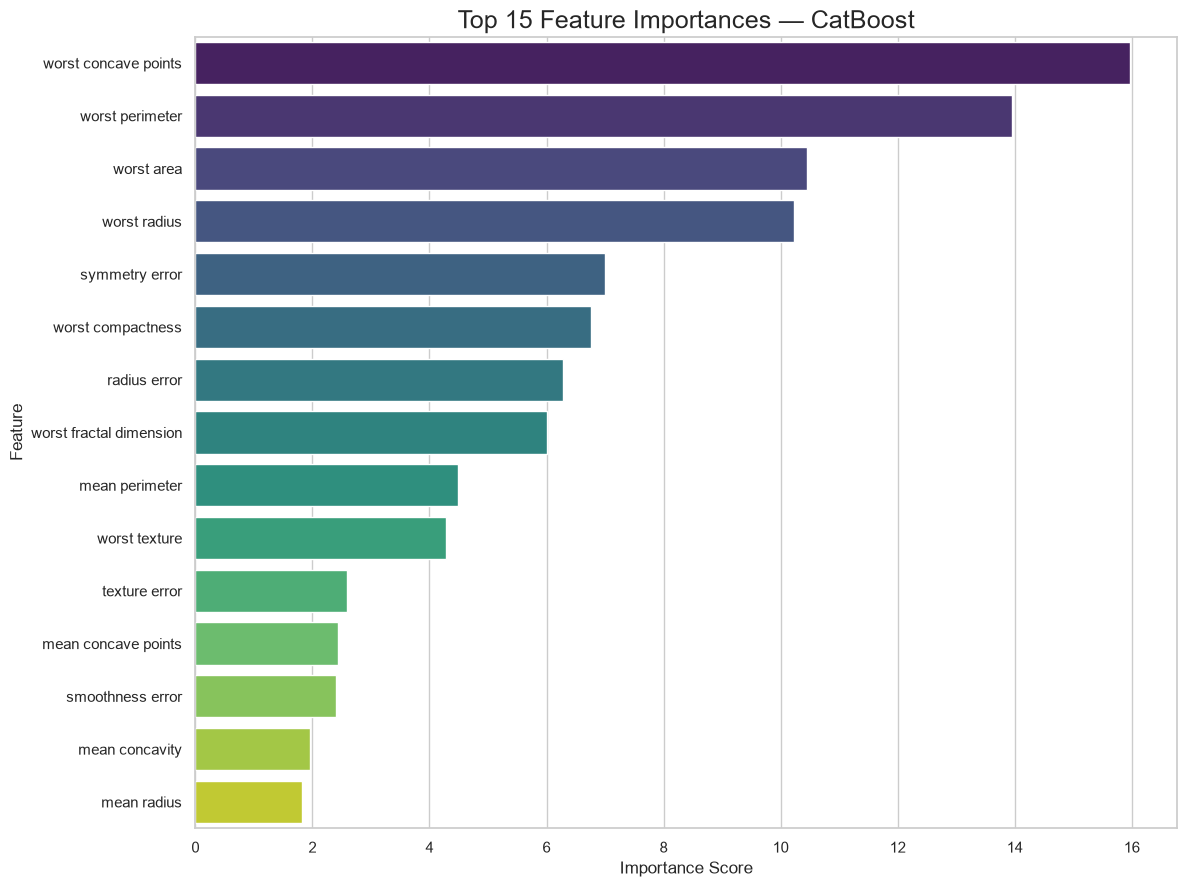

In [20]:
top_features = feature_importance.head(15)

plt.figure(figsize=(12, 9))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature",
    hue="Feature",
    palette="viridis",
    legend=False
)

plt.title(
    "Top 15 Feature Importances — CatBoost",
    fontsize=18
)

plt.xlabel("Importance Score")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

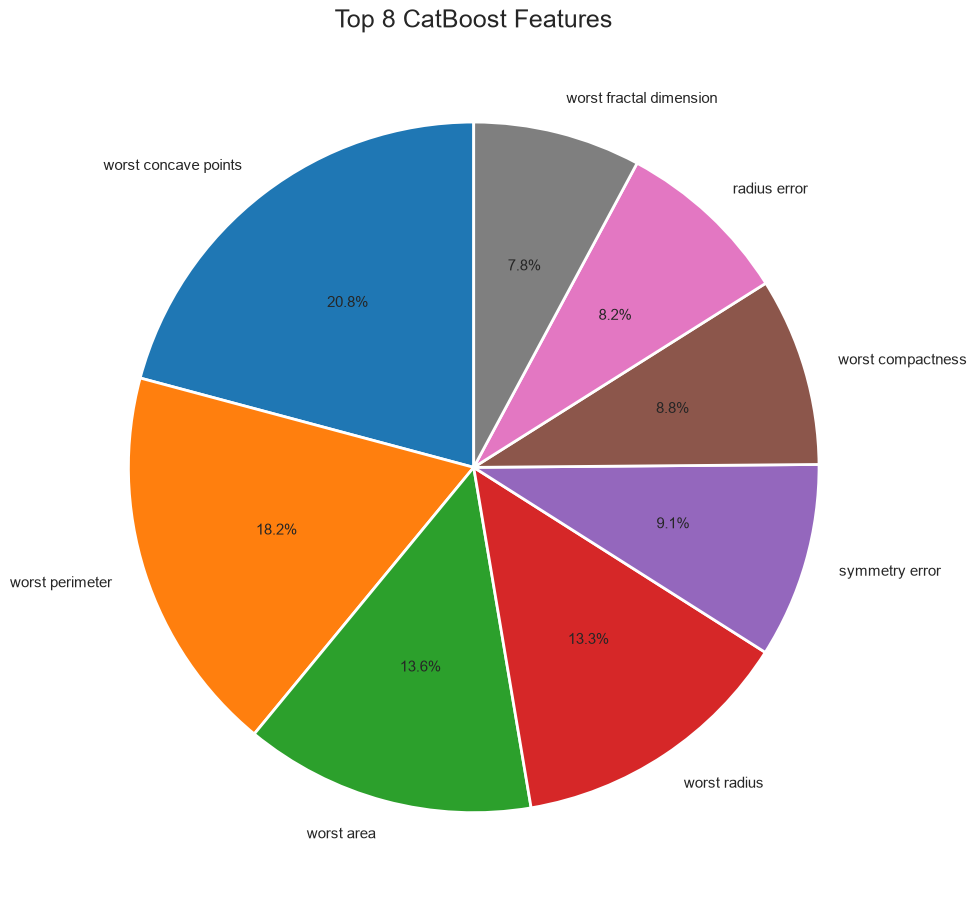

In [21]:
top_8 = feature_importance.head(8)

plt.figure(figsize=(10, 10))

plt.pie(
    top_8["Importance"],
    labels=top_8["Feature"],
    autopct="%1.1f%%",
    startangle=90,
    colors=sns.color_palette(
        "tab10",
        len(top_8)
    ),
    wedgeprops={
        "edgecolor": "white",
        "linewidth": 2
    }
)

plt.title(
    "Top 8 CatBoost Features",
    fontsize=18
)

plt.tight_layout()
plt.show()

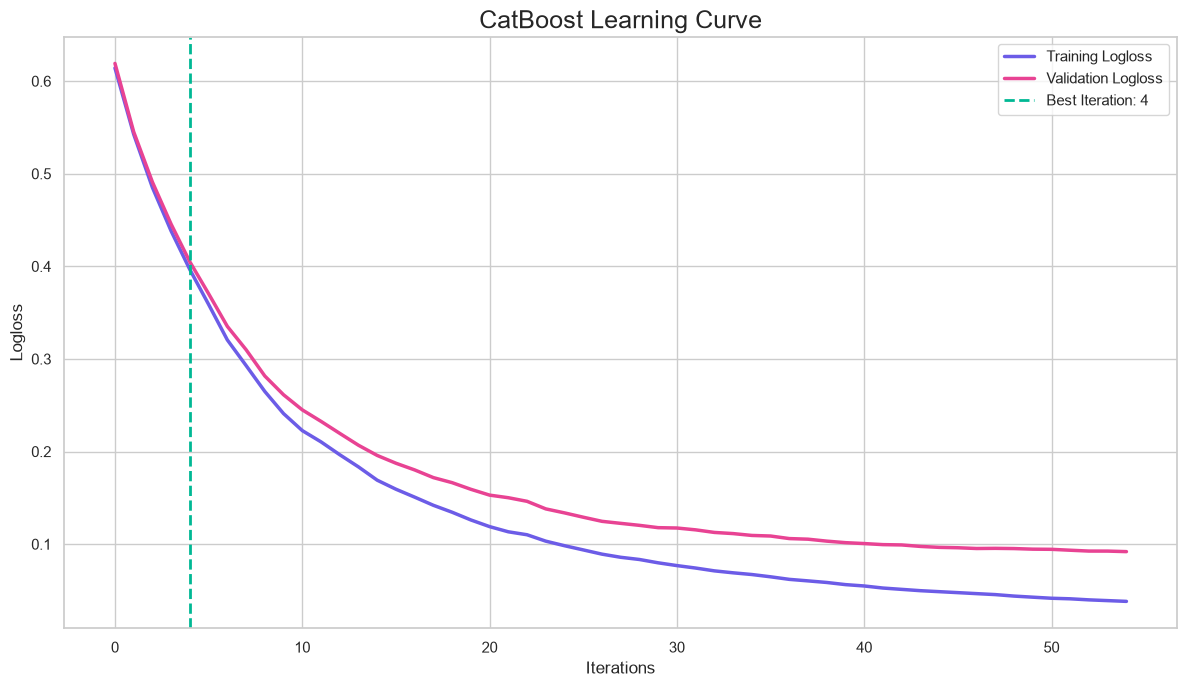

In [22]:
evals_result = model.get_evals_result()

train_logloss = evals_result["learn"]["Logloss"]

validation_logloss = evals_result["validation"]["Logloss"]

plt.figure(figsize=(12, 7))

plt.plot(
    train_logloss,
    label="Training Logloss",
    color="#6C5CE7",
    linewidth=2.5
)

plt.plot(
    validation_logloss,
    label="Validation Logloss",
    color="#E84393",
    linewidth=2.5
)

best_iteration = model.get_best_iteration()

plt.axvline(
    best_iteration,
    color="#00B894",
    linestyle="--",
    linewidth=2,
    label=f"Best Iteration: {best_iteration}"
)

plt.title(
    "CatBoost Learning Curve",
    fontsize=18
)

plt.xlabel("Iterations")
plt.ylabel("Logloss")
plt.legend()

plt.tight_layout()
plt.show()

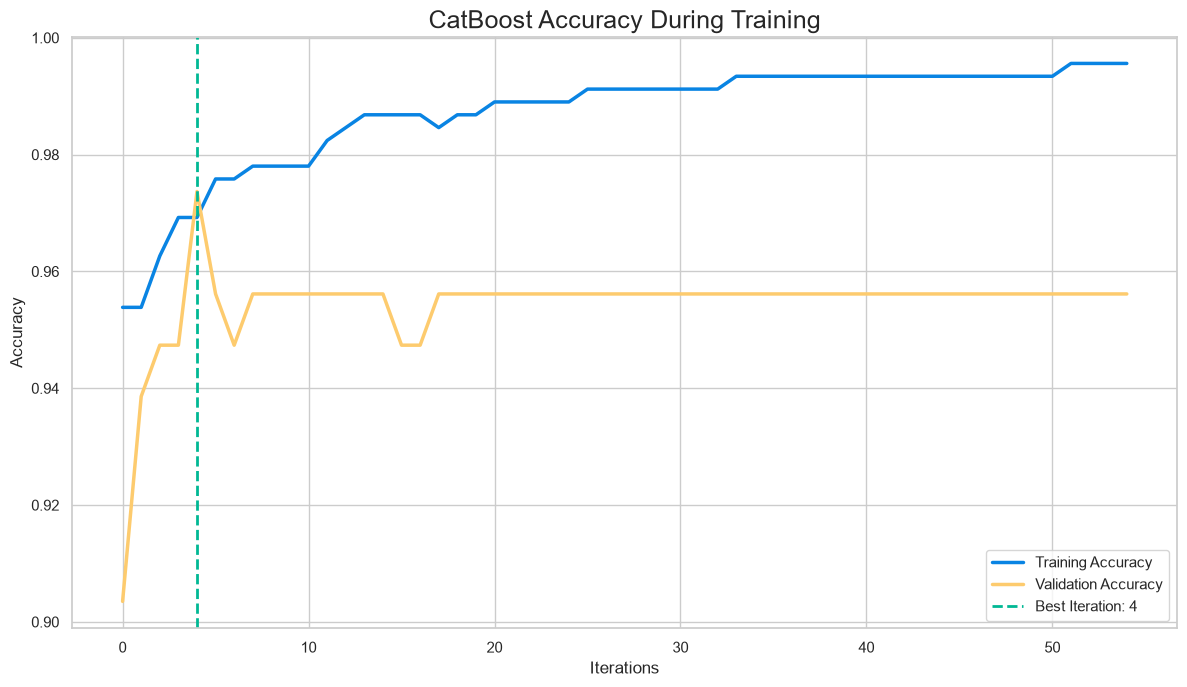

In [23]:
train_accuracy_history = evals_result["learn"]["Accuracy"]

validation_accuracy_history = evals_result["validation"]["Accuracy"]

plt.figure(figsize=(12, 7))

plt.plot(
    train_accuracy_history,
    label="Training Accuracy",
    color="#0984E3",
    linewidth=2.5
)

plt.plot(
    validation_accuracy_history,
    label="Validation Accuracy",
    color="#FDCB6E",
    linewidth=2.5
)

plt.axvline(
    model.get_best_iteration(),
    color="#00B894",
    linestyle="--",
    linewidth=2,
    label=f"Best Iteration: {model.get_best_iteration()}"
)

plt.title(
    "CatBoost Accuracy During Training",
    fontsize=18
)

plt.xlabel("Iterations")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

In [24]:
learning_rates = [
    0.01,
    0.03,
    0.05,
    0.10,
    0.15,
    0.20
]

learning_rate_results = []

for lr in learning_rates:

    temp_model = CatBoostClassifier(
        iterations=500,
        learning_rate=lr,
        depth=6,
        loss_function="Logloss",
        random_seed=42,
        verbose=False
    )

    temp_model.fit(
        X_train,
        y_train
    )

    predictions = temp_model.predict(
        X_test
    ).flatten()

    accuracy = accuracy_score(
        y_test,
        predictions
    )

    learning_rate_results.append(
        accuracy
    )

lr_df = pd.DataFrame({
    "Learning Rate": learning_rates,
    "Accuracy": learning_rate_results
})

display(lr_df)

,Learning Rate,Accuracy
0,0.01,0.956140
1,0.03,0.956140
2,0.05,0.956140
3,0.10,0.964912
4,0.15,0.947368
5,0.20,0.956140


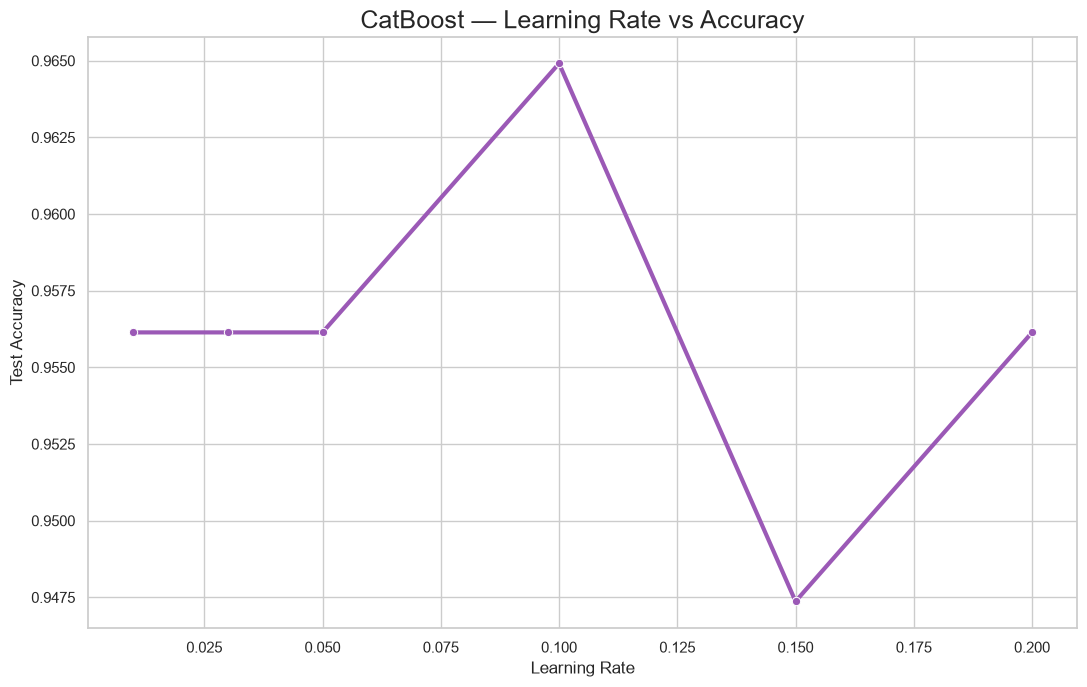

In [25]:
plt.figure(figsize=(11, 7))

sns.lineplot(
    data=lr_df,
    x="Learning Rate",
    y="Accuracy",
    marker="o",
    linewidth=3,
    color="#9B59B6"
)

plt.title(
    "CatBoost — Learning Rate vs Accuracy",
    fontsize=18
)

plt.xlabel("Learning Rate")
plt.ylabel("Test Accuracy")

plt.tight_layout()
plt.show()

In [26]:
depth_values = [
    3,
    4,
    5,
    6,
    7,
    8,
    10
]

depth_results = []

for depth in depth_values:

    temp_model = CatBoostClassifier(
        iterations=500,
        learning_rate=0.05,
        depth=depth,
        loss_function="Logloss",
        random_seed=42,
        verbose=False
    )

    temp_model.fit(
        X_train,
        y_train
    )

    predictions = temp_model.predict(
        X_test
    ).flatten()

    accuracy = accuracy_score(
        y_test,
        predictions
    )

    depth_results.append(
        accuracy
    )

depth_df = pd.DataFrame({
    "Depth": depth_values,
    "Accuracy": depth_results
})

display(depth_df)

,Depth,Accuracy
0,3,0.956140
1,4,0.956140
2,5,0.964912
3,6,0.956140
4,7,0.956140
5,8,0.964912
6,10,0.964912


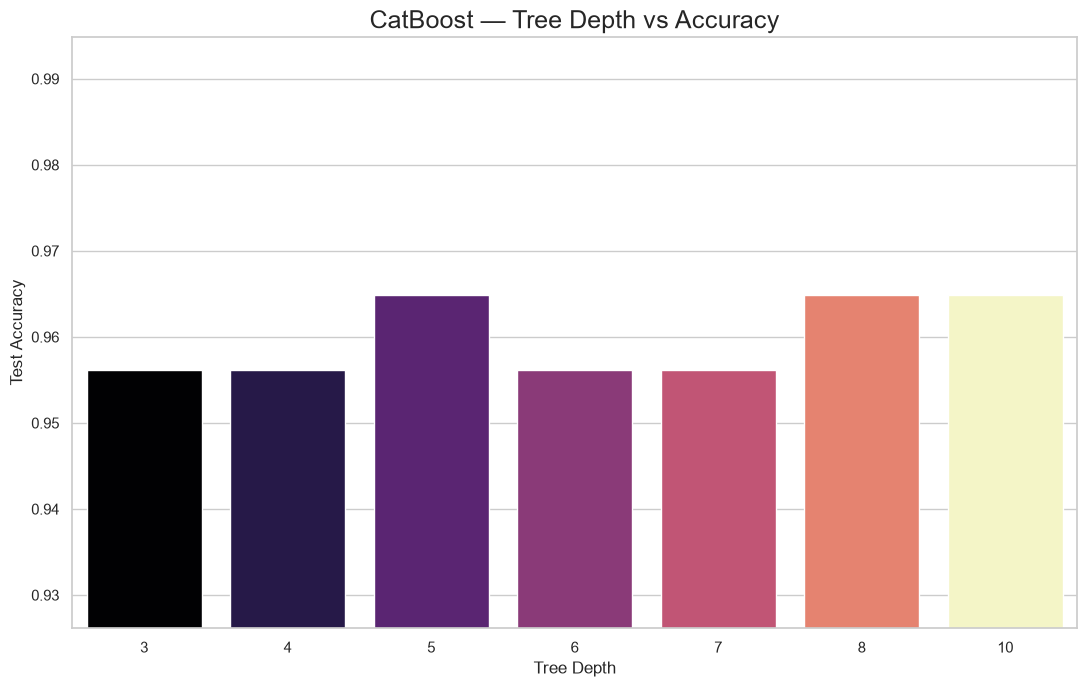

In [27]:
plt.figure(figsize=(11, 7))

sns.barplot(
    data=depth_df,
    x="Depth",
    y="Accuracy",
    hue="Depth",
    palette="magma",
    legend=False
)

plt.title(
    "CatBoost — Tree Depth vs Accuracy",
    fontsize=18
)

plt.xlabel("Tree Depth")
plt.ylabel("Test Accuracy")

plt.ylim(
    max(0, depth_df["Accuracy"].min() - 0.03),
    min(1, depth_df["Accuracy"].max() + 0.03)
)

plt.tight_layout()
plt.show()

,Iterations,Accuracy
0,50,0.95614
1,100,0.95614
2,200,0.95614
3,300,0.95614
4,400,0.95614
5,500,0.95614
6,700,0.95614
7,900,0.95614


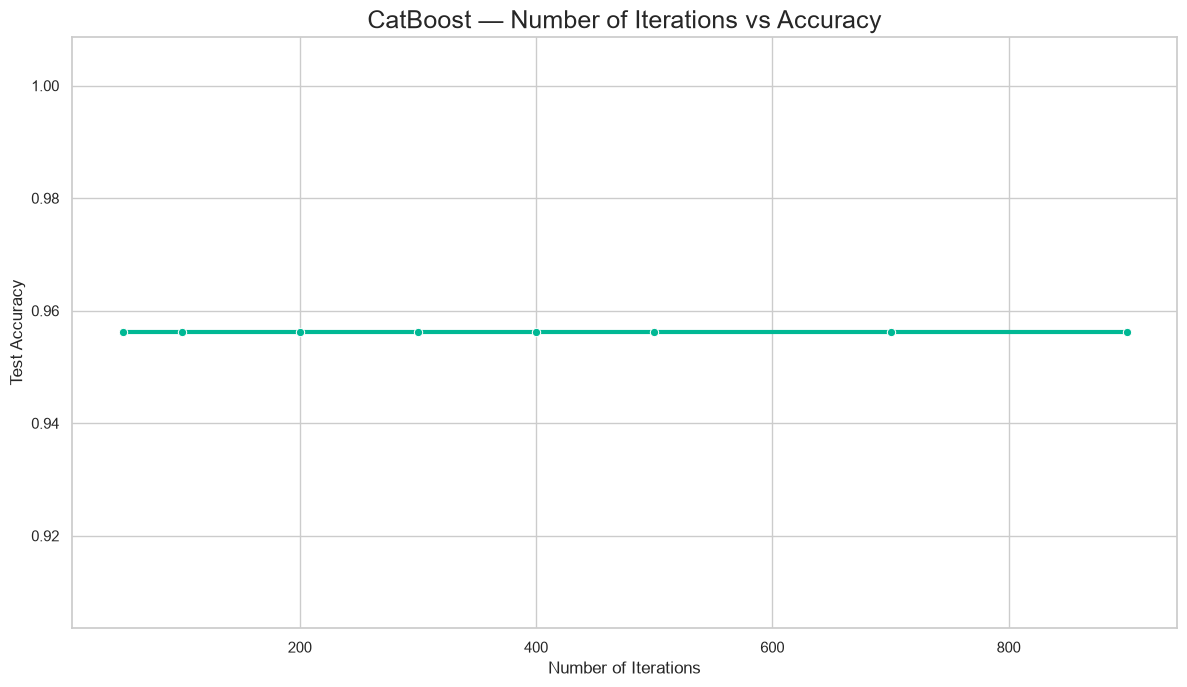

In [28]:
iteration_values = [
    50,
    100,
    200,
    300,
    400,
    500,
    700,
    900
]

iteration_results = []

for n in iteration_values:

    temp_model = CatBoostClassifier(
        iterations=n,
        learning_rate=0.05,
        depth=6,
        loss_function="Logloss",
        random_seed=42,
        verbose=False
    )

    temp_model.fit(
        X_train,
        y_train
    )

    predictions = temp_model.predict(
        X_test
    ).flatten()

    accuracy = accuracy_score(
        y_test,
        predictions
    )

    iteration_results.append(
        accuracy
    )

iteration_df = pd.DataFrame({
    "Iterations": iteration_values,
    "Accuracy": iteration_results
})

display(iteration_df)

plt.figure(figsize=(12, 7))

sns.lineplot(
    data=iteration_df,
    x="Iterations",
    y="Accuracy",
    marker="o",
    linewidth=3,
    color="#00B894"
)

plt.title(
    "CatBoost — Number of Iterations vs Accuracy",
    fontsize=18
)

plt.xlabel("Number of Iterations")
plt.ylabel("Test Accuracy")

plt.tight_layout()
plt.show()

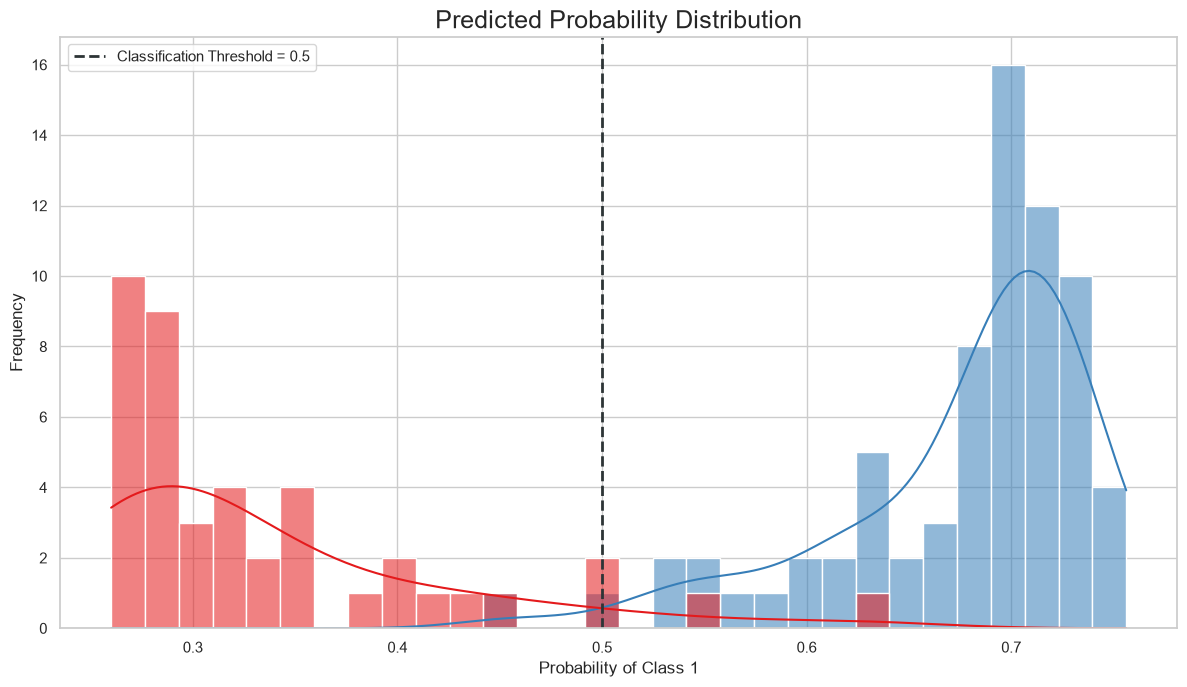

In [29]:
probability_df = pd.DataFrame({
    "Probability": y_test_proba,
    "Actual Class": y_test.values
})

plt.figure(figsize=(12, 7))

sns.histplot(
    data=probability_df,
    x="Probability",
    hue="Actual Class",
    bins=30,
    kde=True,
    palette="Set1",
    alpha=0.55
)

plt.axvline(
    0.5,
    color="#2D3436",
    linestyle="--",
    linewidth=2,
    label="Classification Threshold = 0.5"
)

plt.title(
    "Predicted Probability Distribution",
    fontsize=18
)

plt.xlabel("Probability of Class 1")
plt.ylabel("Frequency")
plt.legend()

plt.tight_layout()
plt.show()

In [30]:
confidence = np.maximum(
    y_test_proba,
    1 - y_test_proba
)

confidence_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_test_pred,
    "Probability_Class_1": y_test_proba,
    "Confidence": confidence
})

confidence_df = confidence_df.sort_values(
    by="Confidence",
    ascending=False
)

display(
    confidence_df.head(20)
)

,Actual,Predicted,Probability_Class_1,Confidence
1,1,1,0.756199,0.756199
95,1,1,0.756199,0.756199
56,1,1,0.743452,0.743452
97,1,1,0.743333,0.743333
9,0,0,0.260078,0.739922
0,0,0,0.260078,0.739922
109,0,0,0.260563,0.739437
7,0,0,0.260563,0.739437
39,0,0,0.260563,0.739437
105,0,0,0.262720,0.737280


In [31]:
misclassified = confidence_df[
    confidence_df["Actual"] != confidence_df["Predicted"]
]

print(
    "Number of Misclassified Samples:",
    len(misclassified)
)

display(misclassified)

Number of Misclassified Samples: 3


,Actual,Predicted,Probability_Class_1,Confidence
35,0,1,0.627111,0.627111
65,0,1,0.557122,0.557122
3,1,0,0.455882,0.544118


In [32]:
print("=" * 75)
print("CATBOOST CLASSIFIER — FINAL MODEL SUMMARY")
print("=" * 75)

print("\nDataset")
print("-" * 75)
print(f"Training Samples : {len(X_train):,}")
print(f"Testing Samples  : {len(X_test):,}")
print(f"Features         : {X.shape[1]}")
print(f"Classes          : {len(np.unique(y))}")

print("\nModel Parameters")
print("-" * 75)
print(f"Iterations       : {model.get_param('iterations')}")
print(f"Learning Rate    : {model.get_param('learning_rate')}")
print(f"Depth            : {model.get_param('depth')}")
print(f"Loss Function    : {model.get_param('loss_function')}")

print("\nTraining Performance")
print("-" * 75)
print(f"Accuracy         : {train_accuracy:.4f}")
print(f"Precision        : {train_precision:.4f}")
print(f"Recall           : {train_recall:.4f}")
print(f"F1 Score         : {train_f1:.4f}")

print("\nTesting Performance")
print("-" * 75)
print(f"Accuracy         : {test_accuracy:.4f}")
print(f"Precision        : {test_precision:.4f}")
print(f"Recall           : {test_recall:.4f}")
print(f"F1 Score         : {test_f1:.4f}")
print(f"ROC-AUC          : {auc_score:.4f}")

print("\nOptimization")
print("-" * 75)
print(f"Best Iteration   : {model.get_best_iteration()}")

print("=" * 75)

CATBOOST CLASSIFIER — FINAL MODEL SUMMARY

Dataset
---------------------------------------------------------------------------
Training Samples : 455
Testing Samples  : 114
Features         : 30
Classes          : 2

Model Parameters
---------------------------------------------------------------------------
Iterations       : 700
Learning Rate    : 0.05
Depth            : 6
Loss Function    : Logloss

Training Performance
---------------------------------------------------------------------------
Accuracy         : 0.9692
Precision        : 0.9689
Recall           : 0.9825
F1 Score         : 0.9756

Testing Performance
---------------------------------------------------------------------------
Accuracy         : 0.9737
Precision        : 0.9726
Recall           : 0.9861
F1 Score         : 0.9793
ROC-AUC          : 0.9931

Optimization
---------------------------------------------------------------------------
Best Iteration   : 4


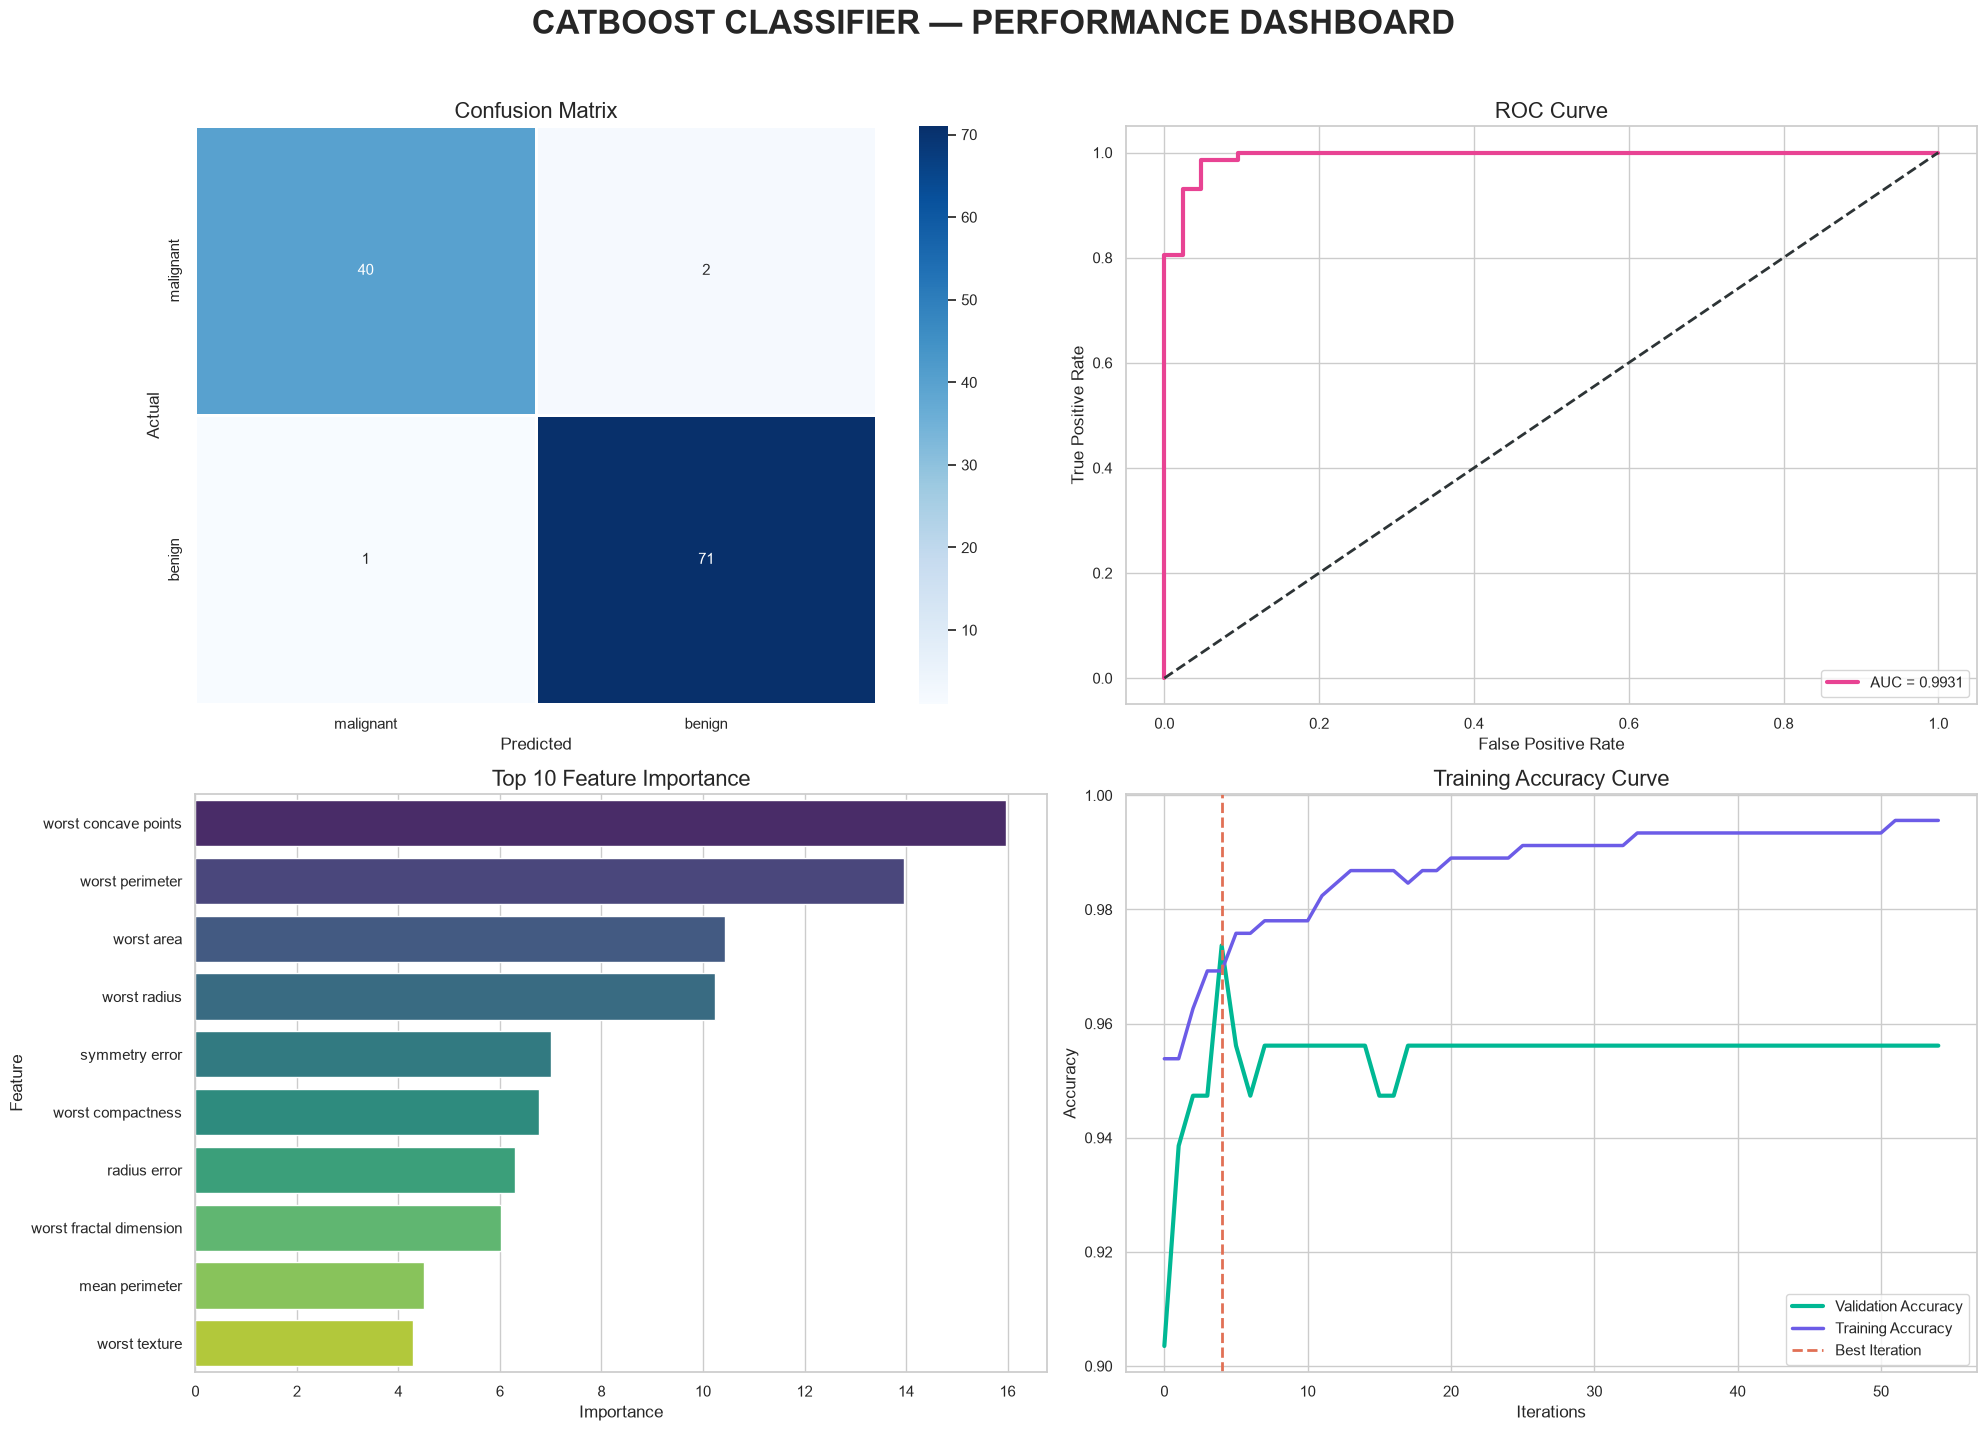

In [33]:
fig = plt.figure(
    figsize=(20, 14)
)

ax1 = plt.subplot(2, 2, 1)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    linewidths=1,
    xticklabels=data.target_names,
    yticklabels=data.target_names,
    ax=ax1
)

ax1.set_title(
    "Confusion Matrix",
    fontsize=16
)

ax1.set_xlabel("Predicted")
ax1.set_ylabel("Actual")


ax2 = plt.subplot(2, 2, 2)

ax2.plot(
    fpr,
    tpr,
    color="#E84393",
    linewidth=3,
    label=f"AUC = {auc_score:.4f}"
)

ax2.plot(
    [0, 1],
    [0, 1],
    "--",
    color="#2D3436",
    linewidth=2
)

ax2.set_title(
    "ROC Curve",
    fontsize=16
)

ax2.set_xlabel("False Positive Rate")
ax2.set_ylabel("True Positive Rate")
ax2.legend()


ax3 = plt.subplot(2, 2, 3)

sns.barplot(
    data=feature_importance.head(10),
    x="Importance",
    y="Feature",
    hue="Feature",
    palette="viridis",
    legend=False,
    ax=ax3
)

ax3.set_title(
    "Top 10 Feature Importance",
    fontsize=16
)


ax4 = plt.subplot(2, 2, 4)

ax4.plot(
    validation_accuracy_history,
    color="#00B894",
    linewidth=3,
    label="Validation Accuracy"
)

ax4.plot(
    train_accuracy_history,
    color="#6C5CE7",
    linewidth=2.5,
    label="Training Accuracy"
)

ax4.axvline(
    model.get_best_iteration(),
    color="#E17055",
    linestyle="--",
    linewidth=2,
    label="Best Iteration"
)

ax4.set_title(
    "Training Accuracy Curve",
    fontsize=16
)

ax4.set_xlabel("Iterations")
ax4.set_ylabel("Accuracy")
ax4.legend()


plt.suptitle(
    "CATBOOST CLASSIFIER — PERFORMANCE DASHBOARD",
    fontsize=24,
    fontweight="bold",
    y=1.02
)

plt.tight_layout()
plt.show()